# Notebook 06: Model Explainability & SHAP Analysis

Using SHAP (SHapley Additive exPlanations) to explain global feature importance and individual claim risk predictions.

In [1]:
import os, sys, joblib
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

model_path = '../models/best_model.joblib' if os.path.exists('../models/best_model.joblib') else 'models/best_model.joblib'
pipeline = joblib.load(model_path)

test_path = '../data/processed/test.csv' if os.path.exists('../data/processed/test.csv') else 'data/processed/test.csv'
test_df = pd.read_csv(test_path)

X_test = test_df.drop(columns=['fraud_reported'])
y_test = test_df['fraud_reported']

from src.feature_engineering import create_engineered_features
from src.preprocessing import drop_uninformative_columns

X_test_clean = drop_uninformative_columns(create_engineered_features(X_test))
preprocessor = pipeline.named_steps['preprocessor']
classifier = pipeline.named_steps['classifier']

X_test_trans = preprocessor.transform(X_test_clean)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(classifier, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test_trans)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print("SHAP Explainer initialized successfully! Shape:", np.shape(shap_vals))


/Users/johnpraneeth/Insurance fraud claims detection enegine/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP Explainer initialized successfully! Shape: (200, 172)


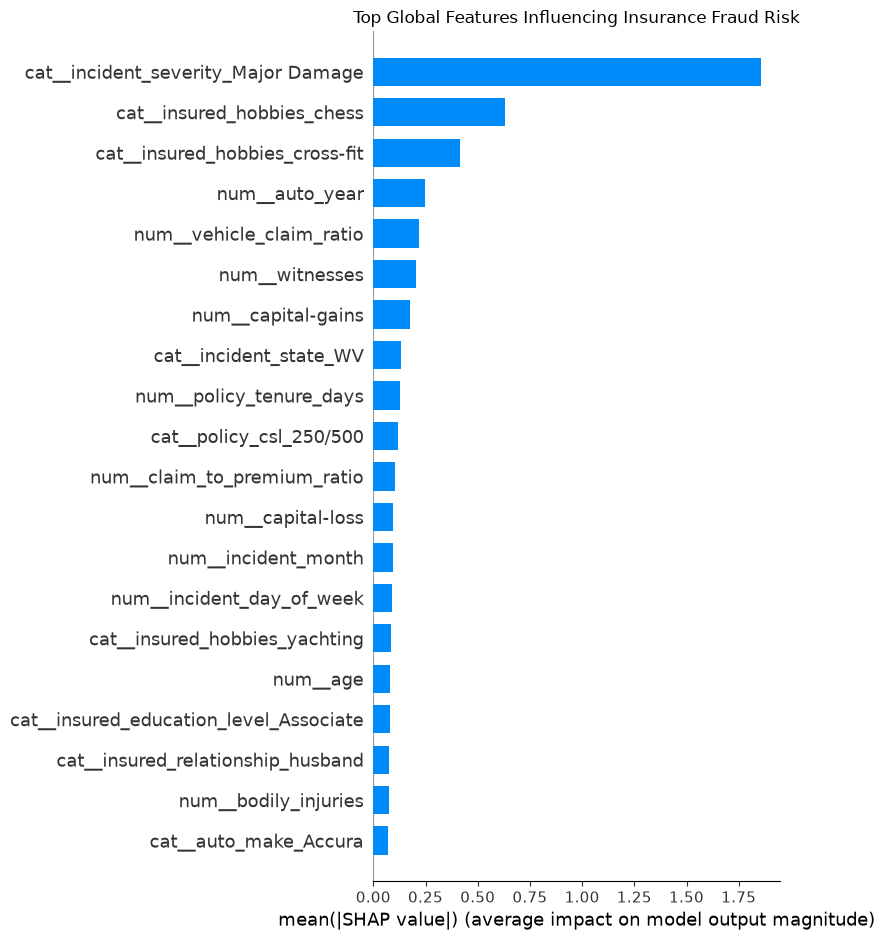

In [2]:
# Global Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_trans, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Top Global Features Influencing Insurance Fraud Risk")
plt.tight_layout()
plt.show()
